# Домашнее задание: архитектуры сверточных сетей на EMNIST

Цель работы: сравнить готовые архитектуры CNN из `torchvision.models` на датасете `EMNIST` со split `balanced`.

В этом ноутбуке обучаются с нуля четыре модели: ResNet18, VGG16, Inception v3 и DenseNet161. Предобученные веса не используются.

## 1. Импорты и настройки

Импортируем библиотеки и задаем основные параметры эксперимента. По условию `EPOCHS = 2`; при наличии вычислительных ресурсов это значение можно увеличить до 10.

In [1]:
import gc
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

SEED = 42

# По заданию параметры обучения вынесены в начало ноутбука.
EPOCHS = 2
BATCH_SIZE = 64
LEARNING_RATE = 0.001

# FAST_MODE нужен только для ускорения запуска при ограниченных ресурсах.
# Если поставить FAST_MODE = False, будет использован полный EMNIST Balanced.
FAST_MODE = True
FAST_TRAIN_SIZE = 12000
FAST_VALIDATION_SIZE = 4000

# При нехватке GPU memory batch size будет автоматически уменьшаться до этого значения.
MIN_BATCH_SIZE = 4

DATA_DIR = Path('data')
NUM_WORKERS = 0

NORMALIZE_MEAN = (0.5, 0.5, 0.5)
NORMALIZE_STD = (0.5, 0.5, 0.5)

## 2. Device и random seed

Фиксируем случайные состояния для воспроизводимости и выбираем CUDA, если она доступна.

In [2]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cuda


## 3. Загрузка и подготовка EMNIST

Используем `torchvision.datasets.EMNIST` со split `balanced`. Количество классов определяется программно.

EMNIST является одноканальным датасетом, поэтому перед подачей в стандартные архитектуры `torchvision` изображения преобразуются в 3 канала через `transforms.Grayscale(num_output_channels=3)`. Для ResNet18, VGG16 и DenseNet161 используется размер 224x224, для Inception v3 - 299x299.

In [3]:
def fix_emnist_orientation(image):
    """Возвращает символы EMNIST в привычную ориентацию."""
    image = transforms.functional.rotate(image, -90)
    image = transforms.functional.hflip(image)
    return image


def make_transform(image_size):
    return transforms.Compose([
        transforms.Lambda(fix_emnist_orientation),
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
    ])


def make_emnist_dataset(train, image_size):
    return datasets.EMNIST(
        root=str(DATA_DIR),
        split='balanced',
        train=train,
        download=True,
        transform=make_transform(image_size),
    )


# Отдельные объекты без resize нужны только для метаданных и размеров split-ов.
metadata_train_dataset = datasets.EMNIST(
    root=str(DATA_DIR),
    split='balanced',
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)
metadata_validation_dataset = datasets.EMNIST(
    root=str(DATA_DIR),
    split='balanced',
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)

NUM_CLASSES = len(metadata_train_dataset.classes)

print(f'Количество классов EMNIST Balanced: {NUM_CLASSES}')
print(f'Полный train split: {len(metadata_train_dataset)} изображений')
print(f'Полный validation/test split: {len(metadata_validation_dataset)} изображений')

100%|██████████| 562M/562M [00:02<00:00, 258MB/s]


Количество классов EMNIST Balanced: 47
Полный train split: 112800 изображений
Полный validation/test split: 18800 изображений


## 4. DataLoader

В режиме `FAST_MODE=True` используется воспроизводимое подмножество данных. Это сделано только из-за ограничений вычислительных ресурсов: четыре большие CNN, обучаемые с нуля на изображениях 224x224 и 299x299, могут обучаться долго.

Официальная test часть EMNIST используется как validation/test для сравнения моделей и не участвует в обучении.

In [4]:
def make_reproducible_subset(dataset, max_size, seed):
    if not FAST_MODE or max_size >= len(dataset):
        return dataset

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:max_size].tolist()
    return Subset(dataset, indices)


def create_dataloaders(image_size, batch_size):
    train_dataset = make_emnist_dataset(train=True, image_size=image_size)
    validation_dataset = make_emnist_dataset(train=False, image_size=image_size)

    train_dataset = make_reproducible_subset(train_dataset, FAST_TRAIN_SIZE, SEED)
    validation_dataset = make_reproducible_subset(validation_dataset, FAST_VALIDATION_SIZE, SEED + 1)

    train_generator = torch.Generator().manual_seed(SEED)
    pin_memory = device.type == 'cuda'

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        generator=train_generator,
    )
    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    return train_loader, validation_loader


example_train_loader, example_validation_loader = create_dataloaders(image_size=224, batch_size=BATCH_SIZE)
example_images, example_labels = next(iter(example_train_loader))

print(f'FAST_MODE: {FAST_MODE}')
print(f'Train объектов в эксперименте: {len(example_train_loader.dataset)}')
print(f'Validation/test объектов в эксперименте: {len(example_validation_loader.dataset)}')
print(f'Форма batch изображений 224x224: {tuple(example_images.shape)}')
print(f'Форма batch меток: {tuple(example_labels.shape)}')

del example_train_loader, example_validation_loader, example_images, example_labels
gc.collect()

FAST_MODE: True
Train объектов в эксперименте: 12000
Validation/test объектов в эксперименте: 4000
Форма batch изображений 224x224: (64, 3, 224, 224)
Форма batch меток: (64,)


0

## 5. Функция создания модели

Все модели создаются с `weights=None`, то есть обучаются с нуля. Для каждой архитектуры заменяется последний классификационный слой под количество классов EMNIST Balanced.

In [5]:
MODEL_CONFIGS = {
    'ResNet18': {'image_size': 224},
    'VGG16': {'image_size': 224},
    'InceptionV3': {'image_size': 299},
    'DenseNet161': {'image_size': 224},
}


def create_model(model_name, num_classes):
    if model_name == 'ResNet18':
        model = models.resnet18(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == 'VGG16':
        model = models.vgg16(weights=None)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)

    elif model_name == 'InceptionV3':
        model = models.inception_v3(weights=None, aux_logits=False, init_weights=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif model_name == 'DenseNet161':
        model = models.densenet161(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    else:
        raise ValueError(f'Неизвестная модель: {model_name}')

    return model


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

## 6. Функции обучения и оценки

Один и тот же код обучения используется для всех четырех моделей. Функции считают средний loss и accuracy, корректно переключают режимы `train` / `eval`, используют `torch.no_grad()` при оценке и переносят данные на выбранное устройство.

In [6]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += batch_size

    average_loss = total_loss / total
    accuracy = correct / total
    return average_loss, accuracy


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += batch_size

    average_loss = total_loss / total
    accuracy = correct / total
    return average_loss, accuracy


def is_out_of_memory_error(error):
    error_text = str(error).lower()
    return 'out of memory' in error_text or 'cuda error: out of memory' in error_text


def train_model(model_name, epochs=EPOCHS, batch_size=BATCH_SIZE):
    image_size = MODEL_CONFIGS[model_name]['image_size']
    current_batch_size = batch_size

    while True:
        model = None
        optimizer = None
        train_loader = None
        validation_loader = None

        try:
            train_loader, validation_loader = create_dataloaders(
                image_size=image_size,
                batch_size=current_batch_size,
            )

            model = create_model(model_name, NUM_CLASSES).to(device)
            parameter_count = count_parameters(model)
            criterion = nn.CrossEntropyLoss()
            optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

            history = {
                'train_loss': [],
                'train_accuracy': [],
                'validation_loss': [],
                'validation_accuracy': [],
            }

            print(f'\n=== {model_name} ===')
            print(f'Размер входа: {image_size}x{image_size}')
            print(f'Batch size: {current_batch_size}')
            print(f'Количество обучаемых параметров: {parameter_count:,}'.replace(',', ' '))

            start_time = time.perf_counter()

            for epoch in range(1, epochs + 1):
                train_loss, train_accuracy = train_one_epoch(
                    model,
                    train_loader,
                    criterion,
                    optimizer,
                    device,
                )
                validation_loss, validation_accuracy = evaluate(
                    model,
                    validation_loader,
                    criterion,
                    device,
                )

                history['train_loss'].append(train_loss)
                history['train_accuracy'].append(train_accuracy)
                history['validation_loss'].append(validation_loss)
                history['validation_accuracy'].append(validation_accuracy)

                print(f'Epoch {epoch}/{epochs}')
                print(f'Train Loss: {train_loss:.4f}')
                print(f'Train Accuracy: {train_accuracy:.2%}')
                print(f'Validation Loss: {validation_loss:.4f}')
                print(f'Validation Accuracy: {validation_accuracy:.2%}')

            training_time = time.perf_counter() - start_time

            result = {
                'model_name': model_name,
                'epochs': epochs,
                'history': history,
                'training_time_sec': training_time,
                'number_of_parameters': parameter_count,
                'batch_size': current_batch_size,
            }

            del model, optimizer, train_loader, validation_loader
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            return result

        except RuntimeError as error:
            if is_out_of_memory_error(error) and current_batch_size > MIN_BATCH_SIZE:
                new_batch_size = max(MIN_BATCH_SIZE, current_batch_size // 2)
                print(
                    f'Недостаточно памяти для {model_name} при batch_size={current_batch_size}. '
                    f'Пробуем batch_size={new_batch_size}.'
                )

                if model is not None:
                    del model
                if optimizer is not None:
                    del optimizer
                if train_loader is not None:
                    del train_loader
                if validation_loader is not None:
                    del validation_loader
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

                current_batch_size = new_batch_size
                continue

            raise

## 7. Сохранение результатов экспериментов

После обучения каждой модели сохраняем историю метрик и строку для итоговой таблицы.

In [7]:
all_histories = {}
comparison_rows = []


def register_result(result):
    model_name = result['model_name']
    history = result['history']

    all_histories[model_name] = history

    row = {
        'Model': model_name,
        'Epochs': result['epochs'],
        'Final Train Loss': history['train_loss'][-1],
        'Final Validation Loss': history['validation_loss'][-1],
        'Validation Accuracy': history['validation_accuracy'][-1],
        'Best Validation Accuracy': max(history['validation_accuracy']),
        'Training Time (sec)': result['training_time_sec'],
        'Number of Parameters': result['number_of_parameters'],
    }

    # Если ячейку модели перезапустить, старая строка заменится новой.
    comparison_rows[:] = [old_row for old_row in comparison_rows if old_row['Model'] != model_name]
    comparison_rows.append(row)

    return row

## 8. ResNet18

In [8]:
resnet18_result = train_model('ResNet18')
register_result(resnet18_result)


=== ResNet18 ===
Размер входа: 224x224
Batch size: 64
Количество обучаемых параметров: 11 200 623
Epoch 1/2
Train Loss: 1.2325
Train Accuracy: 64.60%
Validation Loss: 1.1607
Validation Accuracy: 63.65%
Epoch 2/2
Train Loss: 0.5414
Train Accuracy: 81.64%
Validation Loss: 0.8218
Validation Accuracy: 73.88%


{'Model': 'ResNet18',
 'Epochs': 2,
 'Final Train Loss': 0.5413832090695699,
 'Final Validation Loss': 0.8217576270103455,
 'Validation Accuracy': 0.73875,
 'Best Validation Accuracy': 0.73875,
 'Training Time (sec)': 138.89992449800002,
 'Number of Parameters': 11200623}

## 9. VGG16

In [9]:
vgg16_result = train_model('VGG16')
register_result(vgg16_result)


=== VGG16 ===
Размер входа: 224x224
Batch size: 64
Количество обучаемых параметров: 134 453 103
Epoch 1/2
Train Loss: 4.9132
Train Accuracy: 2.17%
Validation Loss: 3.8503
Validation Accuracy: 1.82%
Epoch 2/2
Train Loss: 3.8498
Train Accuracy: 2.20%
Validation Loss: 3.8505
Validation Accuracy: 2.50%


{'Model': 'VGG16',
 'Epochs': 2,
 'Final Train Loss': 3.8497861099243162,
 'Final Validation Loss': 3.8505342597961425,
 'Validation Accuracy': 0.025,
 'Best Validation Accuracy': 0.025,
 'Training Time (sec)': 425.331474471,
 'Number of Parameters': 134453103}

## 10. Inception v3

In [10]:
inception_v3_result = train_model('InceptionV3')
register_result(inception_v3_result)


=== InceptionV3 ===
Размер входа: 299x299
Batch size: 64
Количество обучаемых параметров: 21 881 871
Epoch 1/2
Train Loss: 1.4597
Train Accuracy: 57.88%
Validation Loss: 0.7869
Validation Accuracy: 74.75%
Epoch 2/2
Train Loss: 0.5669
Train Accuracy: 80.51%
Validation Loss: 0.5433
Validation Accuracy: 82.65%


{'Model': 'InceptionV3',
 'Epochs': 2,
 'Final Train Loss': 0.5669201543331146,
 'Final Validation Loss': 0.54327352809906,
 'Validation Accuracy': 0.8265,
 'Best Validation Accuracy': 0.8265,
 'Training Time (sec)': 481.69053284200004,
 'Number of Parameters': 21881871}

## 11. DenseNet161

In [11]:
densenet161_result = train_model('DenseNet161')
register_result(densenet161_result)


=== DenseNet161 ===
Размер входа: 224x224
Batch size: 64
Количество обучаемых параметров: 26 575 823
Недостаточно памяти для DenseNet161 при batch_size=64. Пробуем batch_size=32.

=== DenseNet161 ===
Размер входа: 224x224
Batch size: 32
Количество обучаемых параметров: 26 575 823
Epoch 1/2
Train Loss: 1.4073
Train Accuracy: 59.02%
Validation Loss: 0.9874
Validation Accuracy: 68.27%
Epoch 2/2
Train Loss: 0.6369
Train Accuracy: 78.10%
Validation Loss: 1.0625
Validation Accuracy: 68.27%


{'Model': 'DenseNet161',
 'Epochs': 2,
 'Final Train Loss': 0.6368503768841426,
 'Final Validation Loss': 1.0624660706520082,
 'Validation Accuracy': 0.68275,
 'Best Validation Accuracy': 0.68275,
 'Training Time (sec)': 668.7659864029997,
 'Number of Parameters': 26575823}

## 12. Графики loss и accuracy

Строим общие графики для всех моделей: train loss, validation/test loss и validation accuracy.

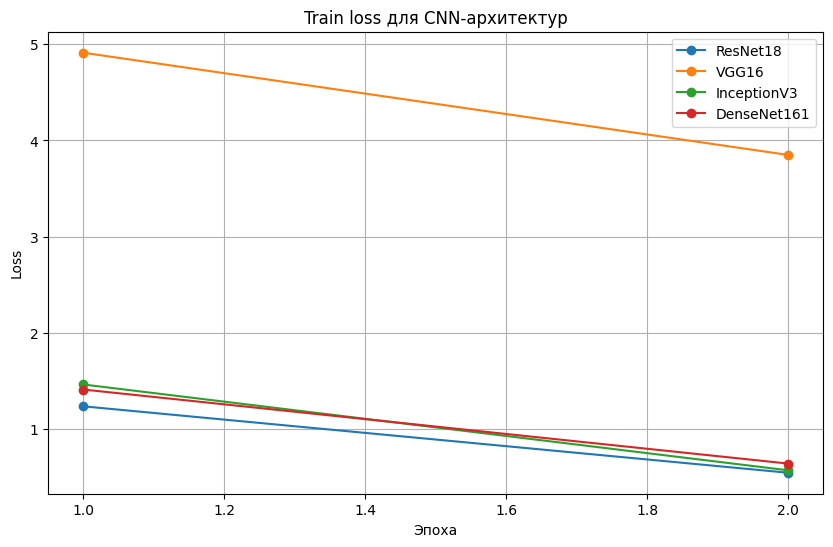

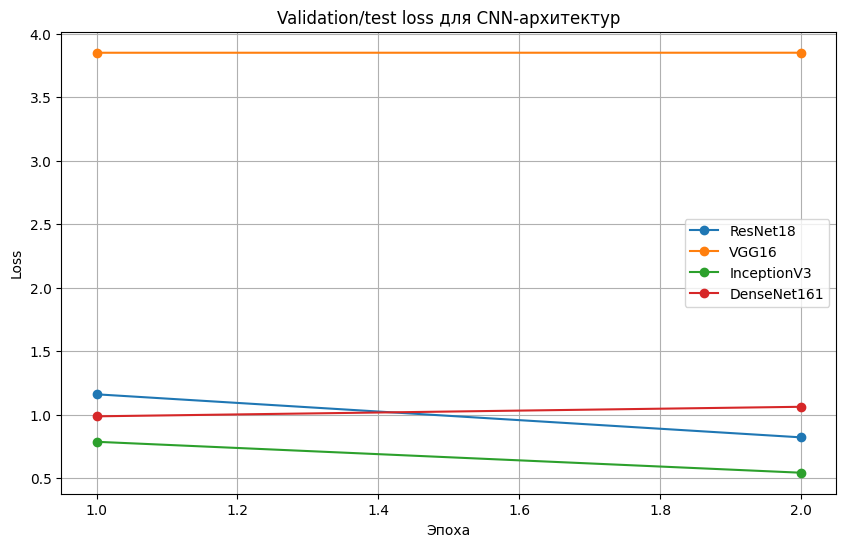

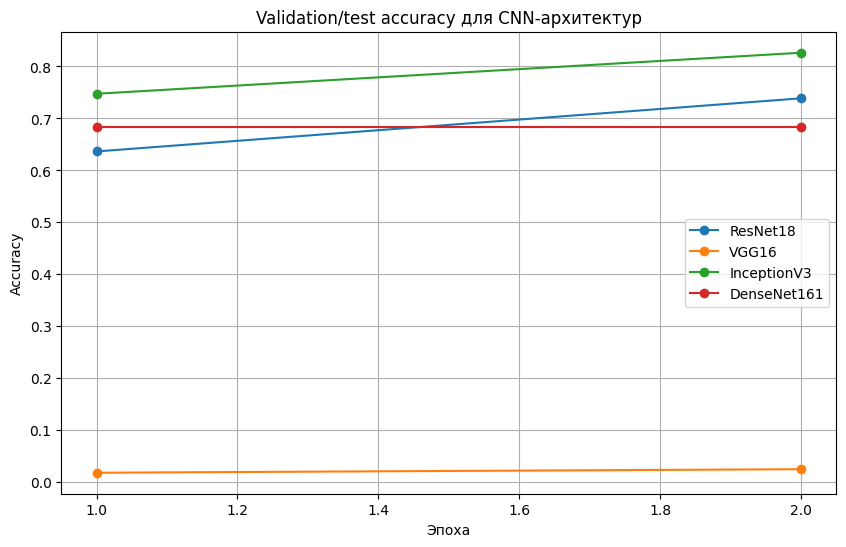

In [12]:
def plot_metric(histories, metric_name, title, y_label):
    plt.figure(figsize=(10, 6))

    for model_name, history in histories.items():
        epochs = range(1, len(history[metric_name]) + 1)
        plt.plot(epochs, history[metric_name], marker='o', label=model_name)

    plt.title(title)
    plt.xlabel('Эпоха')
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_metric(all_histories, 'train_loss', 'Train loss для CNN-архитектур', 'Loss')
plot_metric(all_histories, 'validation_loss', 'Validation/test loss для CNN-архитектур', 'Loss')
plot_metric(all_histories, 'validation_accuracy', 'Validation/test accuracy для CNN-архитектур', 'Accuracy')

## 13. Итоговая таблица

Таблица заполняется фактическими результатами после выполнения обучения. Значения не задаются вручную.

In [13]:
comparison_df = pd.DataFrame(comparison_rows)

column_order = [
    'Model',
    'Epochs',
    'Final Train Loss',
    'Final Validation Loss',
    'Validation Accuracy',
    'Best Validation Accuracy',
    'Training Time (sec)',
    'Number of Parameters',
]

comparison_df = comparison_df[column_order]
display(comparison_df)

,Model,Epochs,Final Train Loss,Final Validation Loss,Validation Accuracy,Best Validation Accuracy,Training Time (sec),Number of Parameters
0,ResNet18,2,0.541383,0.821758,0.73875,0.73875,138.899924,11200623
1,VGG16,2,3.849786,3.850534,0.02500,0.02500,425.331474,134453103
2,InceptionV3,2,0.566920,0.543274,0.82650,0.82650,481.690533,21881871
3,DenseNet161,2,0.636850,1.062466,0.68275,0.68275,668.765986,26575823


## 14. Вывод

Сформируем короткий вывод автоматически на основе полученной таблицы и истории обучения.

In [14]:
best_loss_row = comparison_df.loc[comparison_df['Final Validation Loss'].idxmin()]
best_accuracy_row = comparison_df.loc[comparison_df['Best Validation Accuracy'].idxmax()]
fastest_row = comparison_df.loc[comparison_df['Training Time (sec)'].idxmin()]

print('Краткий вывод по фактическим результатам:')
print(
    f"Минимальный final validation/test loss получила модель "
    f"{best_loss_row['Model']}: {best_loss_row['Final Validation Loss']:.4f}."
)
print(
    f"Максимальная best validation/test accuracy получена у модели "
    f"{best_accuracy_row['Model']}: {best_accuracy_row['Best Validation Accuracy']:.2%}."
)
print(
    f"Быстрее всего обучалась модель {fastest_row['Model']}: "
    f"{fastest_row['Training Time (sec)']:.1f} секунд."
)

print('\nДинамика train loss:')
for model_name, history in all_histories.items():
    if len(history['train_loss']) < 2:
        print(f'{model_name}: для оценки динамики нужно больше одной эпохи.')
    elif history['train_loss'][-1] < history['train_loss'][0]:
        print(f'{model_name}: train loss снизился за время обучения.')
    else:
        print(f'{model_name}: train loss не снизился за время обучения.')

Краткий вывод по фактическим результатам:
Минимальный final validation/test loss получила модель InceptionV3: 0.5433.
Максимальная best validation/test accuracy получена у модели InceptionV3: 82.65%.
Быстрее всего обучалась модель ResNet18: 138.9 секунд.

Динамика train loss:
ResNet18: train loss снизился за время обучения.
VGG16: train loss снизился за время обучения.
InceptionV3: train loss снизился за время обучения.
DenseNet161: train loss снизился за время обучения.
